# Tech Challenge 3

## Dataset
    eCommerce behavior data from multi category store
    https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## EDA - Exploratory Data Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carregando os dados localmente
df = pd.read_csv(r"C:\WORK\FIAP-PosMLE\Tech Challenge 3\techchallenge03\datasets\2019-Oct-Test10K.csv")

In [ ]:
# Carregando os dados (google drive)
df = pd.read_csv('/content/drive/MyDrive/2019-Oct-Test10K.csv')

### Data Understanding: Geral

In [ ]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [ ]:
df.shape

(9999, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     9999 non-null   object 
 1   event_type     9999 non-null   object 
 2   product_id     9999 non-null   int64  
 3   category_id    9999 non-null   int64  
 4   category_code  6722 non-null   object 
 5   brand          8557 non-null   object 
 6   price          9999 non-null   float64
 7   user_id        9999 non-null   int64  
 8   user_session   9999 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [ ]:
df.describe()

,product_id,category_id,price,user_id
count,9.999000e+03,9.999000e+03,9999.000000,9.999000e+03
mean,1.023870e+07,2.055768e+18,294.098607,5.314159e+08
std,1.102406e+07,1.392063e+16,365.523534,1.691509e+07
min,1.002099e+06,2.053014e+18,0.000000,3.064418e+08
25%,1.005105e+06,2.053014e+18,62.940000,5.154591e+08
50%,5.100563e+06,2.053014e+18,159.330000,5.281100e+08
75%,1.620031e+07,2.053014e+18,362.940000,5.481027e+08
max,5.300000e+07,2.172371e+18,2574.070000,5.554648e+08


In [ ]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,3277
brand,1442
price,0
user_id,0
user_session,0


In [ ]:
# Quantidade de clientes
num_users = df["user_id"].nunique()
print(num_users)

2867


## Data Understanding e Data Preparation: product_id
Possibilidades:
* Produtos mais vendidos
* Produtos mais visualizados (populares)

In [ ]:
# Quantidade total de produtos
df["product_id"].nunique()

4148

In [ ]:
# 10 produtos mais comprados
df[df['event_type'] == 'purchase']\
  [['product_id', 'category_id', \
    'category_code', 'brand', 'price']]\
    .value_counts().head(10)

,,,,,count
product_id,category_id,category_code,brand,price,
1004856,2053013555631882655,electronics.smartphone,samsung,130.76,5
1004750,2053013555631882655,electronics.smartphone,samsung,197.43,5
1004833,2053013555631882655,electronics.smartphone,samsung,174.76,4
1004246,2053013555631882655,electronics.smartphone,apple,736.18,3
4804295,2053013554658804075,electronics.audio.headphone,xiaomi,23.13,2
4804055,2053013554658804075,electronics.audio.headphone,apple,189.91,2
1004767,2053013555631882655,electronics.smartphone,samsung,254.82,2
1002524,2053013555631882655,electronics.smartphone,apple,515.67,2
1005104,2053013555631882655,electronics.smartphone,apple,975.57,2


In [ ]:
# Compras product_id 1004856
df[df['event_type'] == 'purchase'][df[df['event_type'] == 'purchase']['product_id'] == 1004856]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
162,2019-10-01 00:02:14 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564
2828,2019-10-01 02:23:10 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,550146179,4078566a-62e6-4258-b623-87812d27aa62
3546,2019-10-01 02:25:04 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,555110488,ce885079-4d92-4fe6-92a3-377c5a2d8291
4959,2019-10-01 02:28:09 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543356214,cc27a71b-006f-4028-ad60-46cf26ab06af
9493,2019-10-01 02:36:25 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,551712733,56fbbe83-a130-49bf-bcb4-27a812b7a1a6


In [ ]:
# 10 produtos mais vistos (populares)
df[df['event_type'] == 'view']\
  [['product_id', 'category_id', \
    'category_code', 'brand', 'price']]\
    .value_counts().head(10)

,,,,,count
product_id,category_id,category_code,brand,price,
1004856,2053013555631882655,electronics.smartphone,samsung,130.76,116
1004767,2053013555631882655,electronics.smartphone,samsung,254.82,115
1005115,2053013555631882655,electronics.smartphone,apple,975.57,111
1005105,2053013555631882655,electronics.smartphone,apple,1415.48,65
1004870,2053013555631882655,electronics.smartphone,samsung,286.86,61
1002544,2053013555631882655,electronics.smartphone,apple,464.13,60
1004833,2053013555631882655,electronics.smartphone,samsung,174.76,57
1004249,2053013555631882655,electronics.smartphone,apple,739.81,52
1004750,2053013555631882655,electronics.smartphone,samsung,197.43,41


In [ ]:
# Faturamento - vendas realizadas
df[df['event_type'] == 'purchase']['price'].sum()

np.float64(35757.22000000001)

In [ ]:
# Faturamento não realizado - compras no carrinho
df[df['event_type'] == 'cart']['price'].sum()

np.float64(42652.43)

In [ ]:
# Produtos não faturados - compras no carrinho
df[df['event_type'] == 'cart']['product_id'].unique()

array([ 5100816,  1002524,  4804056,  1004833,  1005003,  1004750,
        1004709,  1004659,  1500021,  1004247, 17301342,  5100719,
        1005135,  1005144,  1005126,  8800448,  1004856,  1004836,
        1004566,  1004650,  3700717,  5100563,  1005098,  1004767,
        1005115,  1002629,  1004870,  1005104,  1004238, 12711630,
       15300183,  1004958,  1801766,  4804295,  1005138,  1004562,
        5100689,  1004446,  3700127,  1005015,  1004741,  1005109,
        1004665,  1004258,  3801162,  1004739,  3601405,  1005112,
        1004893, 10701101,  1004042,  1004834, 17300136,  1005105,
       12703015])

In [ ]:
# Contagem de produtos não faturados segmentados por categoria
df[df['event_type'] == 'cart'][['product_id', 'category_code']].groupby('category_code').count()

,product_id
category_code,
appliances.environment.vacuum,3
appliances.iron,1
appliances.kitchen.washer,1
computers.peripherals.printer,3
electronics.audio.headphone,2
electronics.clocks,4
electronics.smartphone,72
electronics.telephone,1
electronics.video.tv,1


## Data Understanding e Data Preparation: event_time
Possibilidades:
* Identificação de padrões de compras
* Identificação de Funil de conversão ao longo do tempo: view-cart-purchase

In [ ]:
# Tratamento de event_time: separação por data, hora e dia
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day'] = df['event_time'].dt.day
df['weekday'] = df['event_time'].dt.day_name()   # segunda, terça...
df['month'] = df['event_time'].dt.month
df['year'] = df['event_time'].dt.year
df.head(3)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour,day,weekday,month,year
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01,0,1,Tuesday,10,2019
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01,0,1,Tuesday,10,2019
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01,0,1,Tuesday,10,2019


In [ ]:
# organizando colunas
df= df[['event_time','date', 'hour', 'day', 'weekday', 'month', 'year',
    'event_type', 'product_id', 'category_id', 'category_code',
    'brand', 'price', 'user_id', 'user_session']]
df.head(3)

,event_time,date,hour,day,weekday,month,year,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,2019-10-01,0,1,Tuesday,10,2019,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00+00:00,2019-10-01,0,1,Tuesday,10,2019,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01+00:00,2019-10-01,0,1,Tuesday,10,2019,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8


In [ ]:
# Eventos
df['event_type'].value_counts()

,count
event_type,
view,9784
purchase,118
cart,97


<Axes: title={'center': 'Eventos por Dia'}, xlabel='date'>

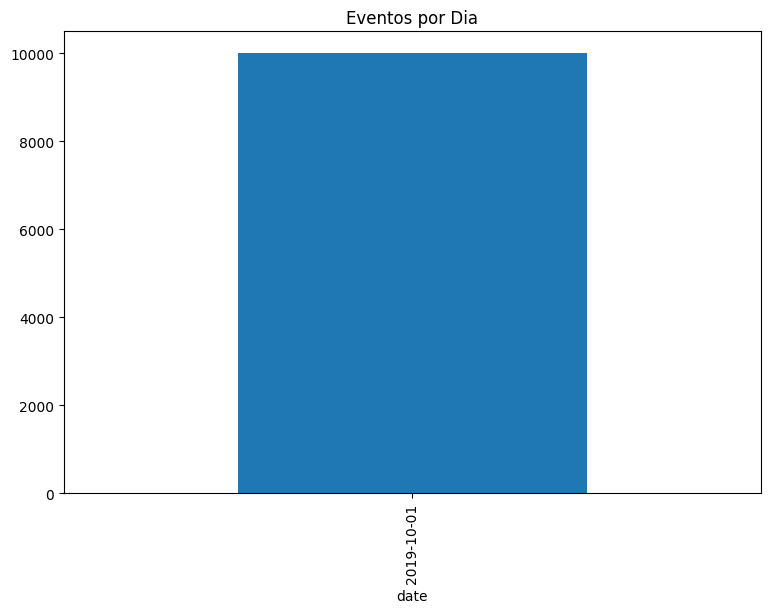

In [ ]:
# Quantidade de eventos por dia
df.groupby('date')['event_type'].count().plot(kind='bar', figsize=(9,6), title="Eventos por Dia")

<Axes: title={'center': 'Eventos por Hora do Dia'}, xlabel='hour'>

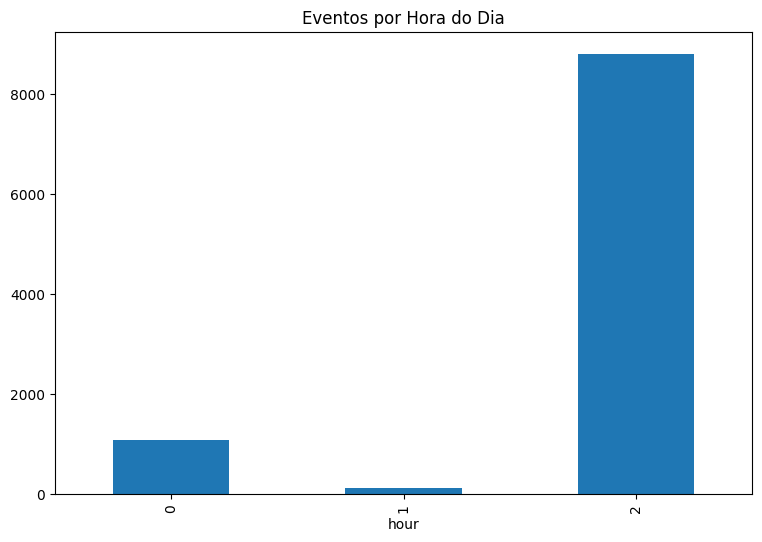

In [ ]:
# Quantidade de eventos por hora
df['hour'].value_counts().sort_index().plot(kind='bar', figsize=(9,6), title="Eventos por Hora do Dia")

<Axes: title={'center': 'Eventos por Tipo ao Longo ddo dia, em horas'}, xlabel='hour'>

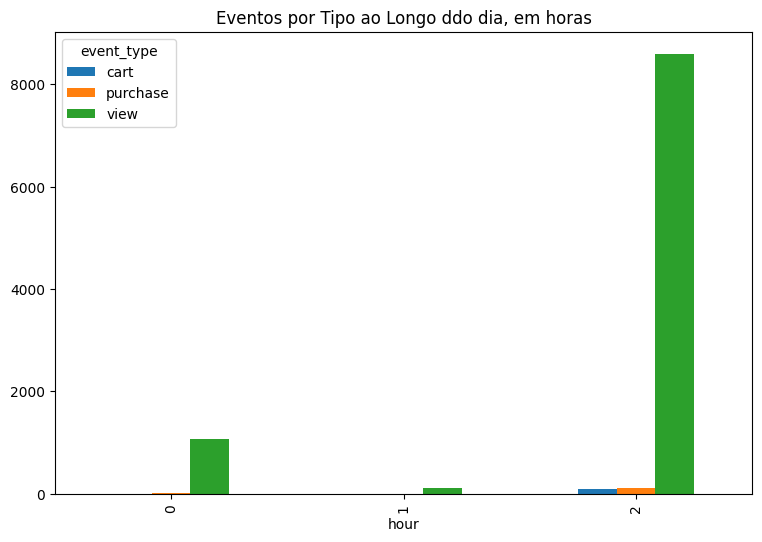

In [ ]:
# Segmento os tipos de eventos por hora
df.groupby(['hour', 'event_type']).size().unstack().plot(kind='bar', figsize=(9,6), title="Eventos por Tipo ao Longo ddo dia, em horas")

<Axes: title={'center': 'Eventos por Dia da Semana'}, xlabel='weekday'>

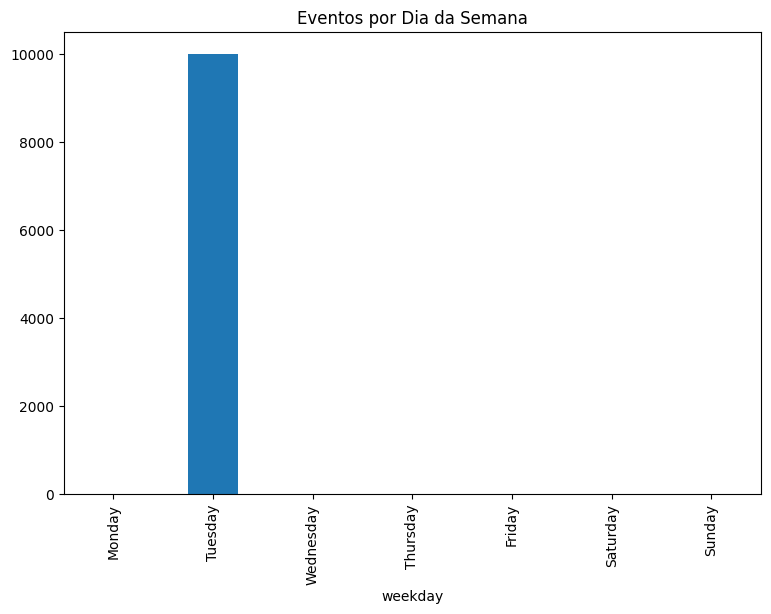

In [ ]:
# Obtendo os eventos por dia da semana
df['weekday'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday',\
     'Friday','Saturday','Sunday'])\
     .plot(kind='bar', figsize=(9,6), title="Eventos por Dia da Semana")

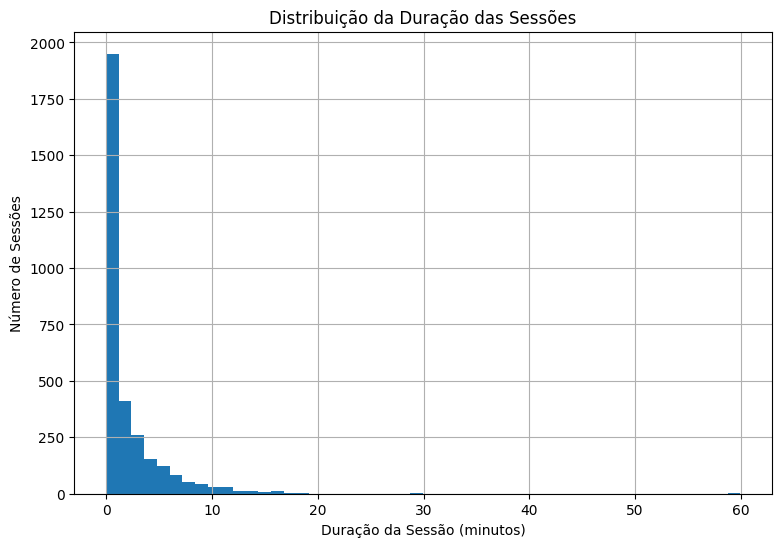

In [ ]:
session_time = df.groupby('user_session')['event_time'].agg(['min','max'])
session_time['duration'] = (session_time['max'] - session_time['min']).dt.total_seconds() / 60
session_time['duration'].hist(bins=50, figsize=(9,6))
plt.xlabel("Duração da Sessão (minutos)")
plt.ylabel("Número de Sessões")
plt.title("Distribuição da Duração das Sessões")
plt.show()

In [ ]:
# Analisando a distribuição do tempo das sessões
session_time['duration'].describe()

,duration
count,3188.000000
mean,1.868272
std,3.165839
min,0.000000
25%,0.000000
50%,0.483333
75%,2.533333
max,59.933333


In [ ]:
# Removendo outliers das sessoes
q95 = session_time['duration'].quantile(0.95)  # limite no p95
filtered = session_time[session_time['duration'] <= q95]

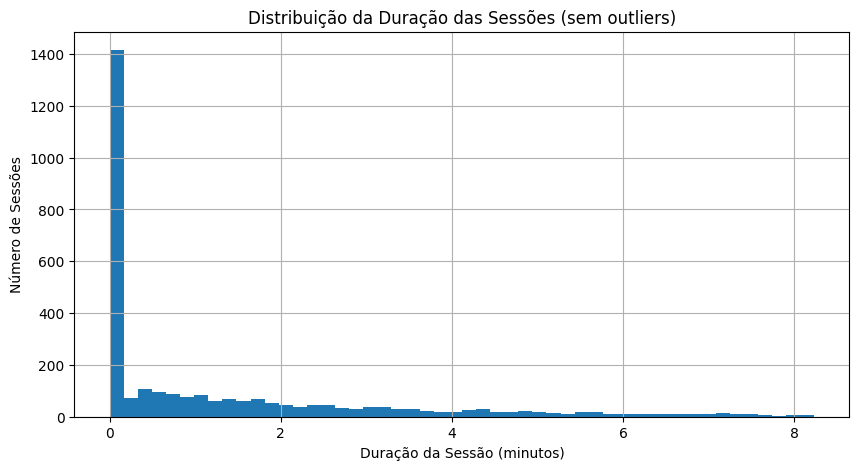

In [ ]:
# Mapa das sessões por tempo em minutos
filtered['duration'].hist(bins=50, figsize=(10,5))
plt.xlabel("Duração da Sessão (minutos)")
plt.ylabel("Número de Sessões")
plt.title("Distribuição da Duração das Sessões (sem outliers)")
plt.show()

## Data Understanding e Data Preparation: event_type
Possibilidades:
* Identificação de padrões de compras
* Análise de Funil de conversão ao longo do tempo: view-cart-purchase
* Identificação de fraude: quantidade de 'cart' menor que 'purchase'

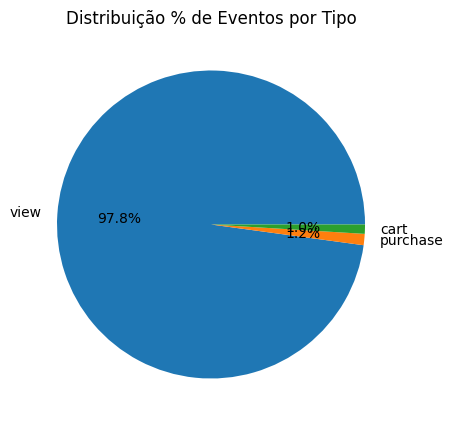

In [ ]:
# Distribuição de eventos por tipo (grafico de pizza)
df['event_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,5))
plt.title("Distribuição % de Eventos por Tipo")
plt.ylabel("")
plt.show()

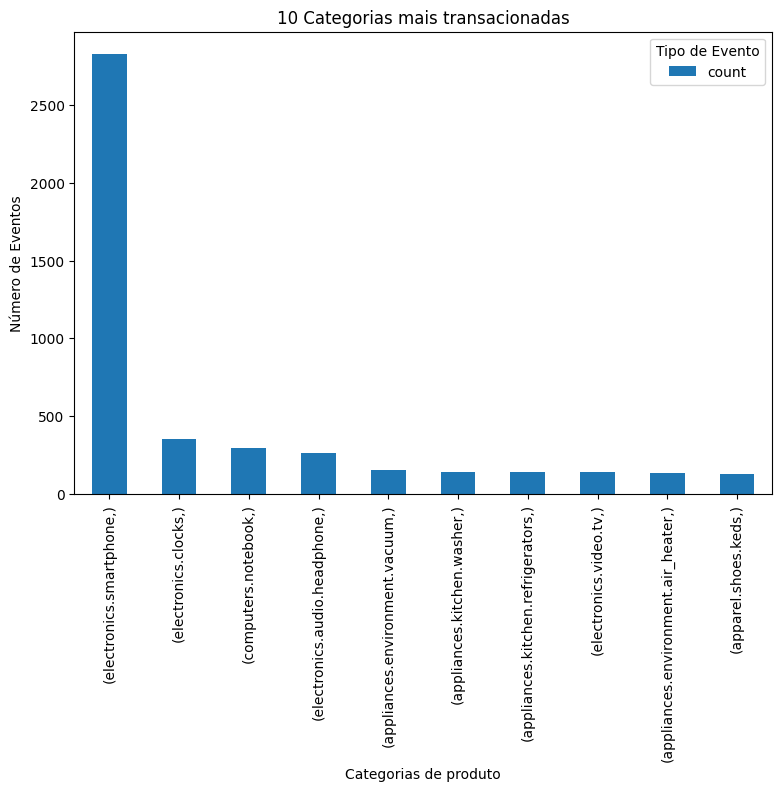

In [ ]:
# 10 Categorias de produtos mais transacionadas
category_code_events= df[['category_code']].value_counts().head(10)

category_code_events.plot(kind='bar', stacked=True, figsize=(9,6))
plt.xlabel("Categorias de produto")
plt.ylabel("Número de Eventos")
plt.title("10 Categorias mais transacionadas")
plt.legend(title="Tipo de Evento")
plt.show()

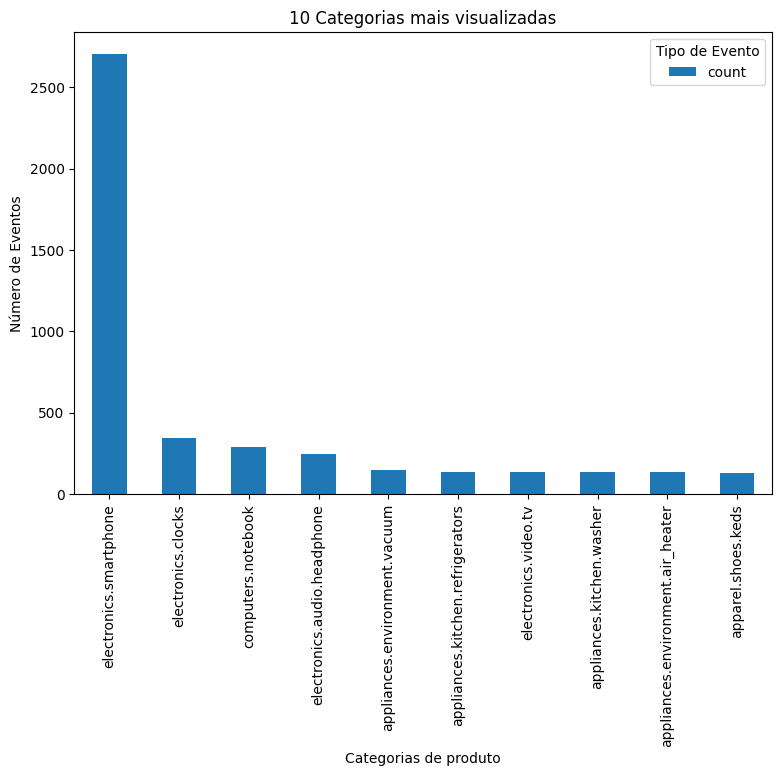

In [ ]:
# 10 Categorias de produtos mais visualizadas
df[df['event_type'] == 'view']['category_code'].value_counts().head(10)\
.plot(kind='bar', stacked=True, figsize=(9,6))
plt.xlabel("Categorias de produto")
plt.ylabel("Número de Eventos")
plt.title("10 Categorias mais visualizadas")
plt.legend(title="Tipo de Evento")
plt.show()

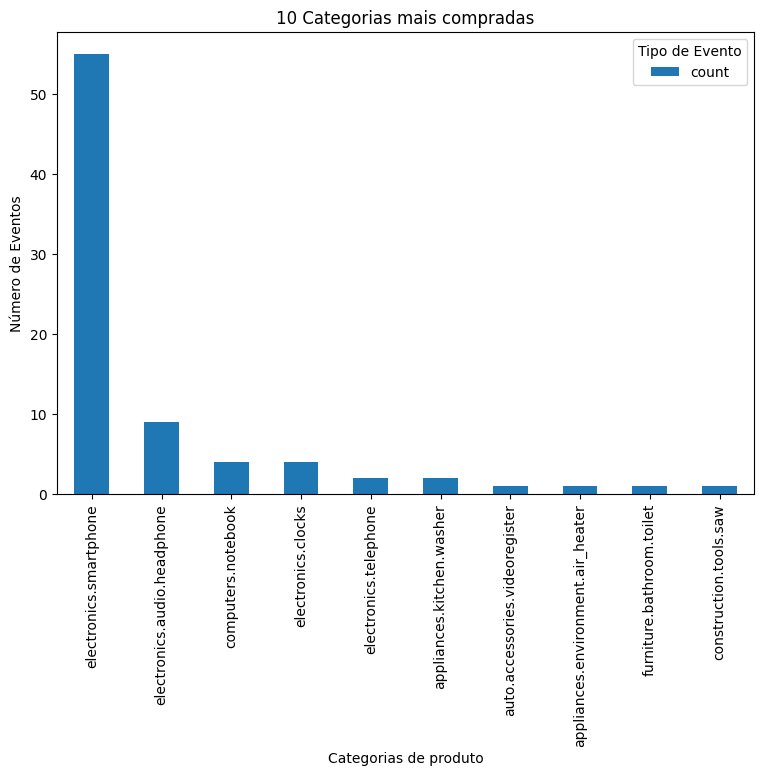

In [ ]:
# 10 Categorias de produtos mais compradas
df[df['event_type'] == 'purchase']['category_code'].value_counts().head(10)\
.plot(kind='bar', stacked=True, figsize=(9,6))
plt.xlabel("Categorias de produto")
plt.ylabel("Número de Eventos")
plt.title("10 Categorias mais compradas")
plt.legend(title="Tipo de Evento")
plt.show()

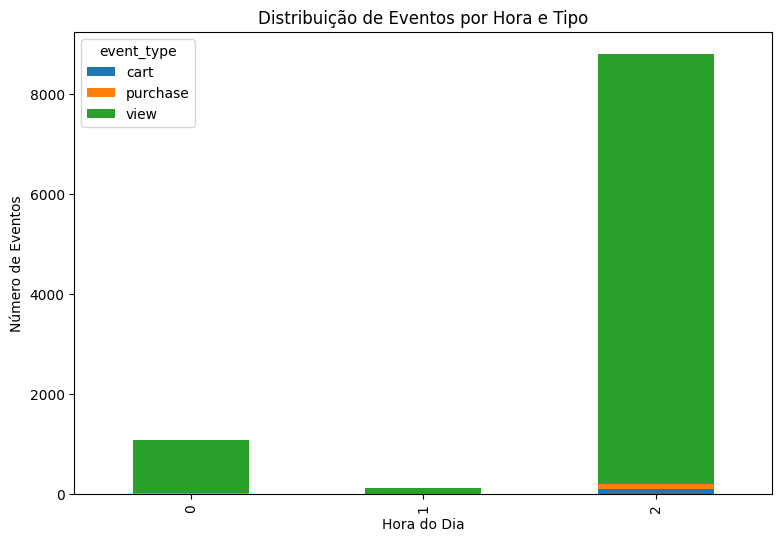

In [ ]:
# Distribuição dos eventos por hora e tipo
df['hour'] = df['event_time'].dt.hour
hourly_events = df.groupby(['hour', 'event_type']).size().unstack()

hourly_events.plot(kind='bar', stacked=True, figsize=(9,6))
plt.xlabel("Hora do Dia")
plt.ylabel("Número de Eventos")
plt.title("Distribuição de Eventos por Hora e Tipo")
plt.show()


## Data Understanding e Data Preparation: category_id /category_code
Possibilidades:
* Identificação de quais categorias tem mais visualizações, adições ao carrinho de compras
* Identificação de quais categorias perdem clientes no funil
* Identificação de Sazonalidade de vendas
* Recomendações de produtos

In [ ]:
list(df.category_code.unique())
print(df['category_code'].value_counts())

category_code
electronics.smartphone               3060
unknown                              2250
electronics.clocks                    350
computers.notebook                    294
electronics.audio.headphone           259
                                     ... 
appliances.kitchen.coffee_grinder       1
auto.accessories.winch                  1
apparel.shirt                           1
sport.tennis                            1
apparel.scarf                           1
Name: count, Length: 100, dtype: int64


In [ ]:
# Tratamento de category_code: para os valores ausentes (NaN) de 'category_code', usar os valores mais frequentes de 'brand'
df['category_code'] = df.groupby('brand')['category_code'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown'))

In [ ]:
# Tratamento de category_code: preenche os valores de category_code à partir de inferência em category_id - preenche com base em IDs conhecidos
mapping = df.dropna().drop_duplicates(subset=['category_id', 'category_code'])
mapping_dict = dict(zip(mapping['category_id'], mapping['category_code']))

In [ ]:
df['category_code'] = df.apply(lambda row: mapping_dict.get(row['category_id'], row['category_code']), axis=1)

In [ ]:
# Tratamento de category_code: para o que restar de NaN, preencher com fillna
df['category_code'] = df['category_code'].fillna('unknown')

In [ ]:
# separa categoria principal e subcategoria
df[['main_category','sub_category']] = df['category_code'].str.split('.', n=1, expand=True)

In [ ]:
df['main_category'].value_counts()

,count
main_category,
electronics,3996
unknown,2250
appliances,1571
computers,623
furniture,604
apparel,284
auto,250
construction,204
accessories,66


In [ ]:
category_event_counts = df.groupby(['main_category', 'event_type']).size().unstack()
category_event_counts

event_type,cart,purchase,view
main_category,,,
accessories,NaN,1.0,65.0
apparel,NaN,1.0,283.0
appliances,5.0,11.0,1555.0
auto,NaN,1.0,249.0
computers,3.0,7.0,613.0
construction,NaN,2.0,202.0
country_yard,NaN,NaN,4.0
electronics,80.0,72.0,3844.0
furniture,NaN,2.0,602.0


In [ ]:
category_event_counts['total_events'] = category_event_counts.sum(axis=1)
#category_event_counts['view_to_cart_rate'] = category_event_counts['cart'] / category_event_counts['view'] * 100
category_event_counts['view_to_cart_rate'] = (category_event_counts['cart'] / category_event_counts['view']) * 100
#category_event_counts['cart_to_purchase_rate'] = category_event_counts['purchase'] / category_event_counts['cart'] * 100
category_event_counts['cart_to_purchase_rate'] = (category_event_counts['purchase'] / category_event_counts['cart']) * 100

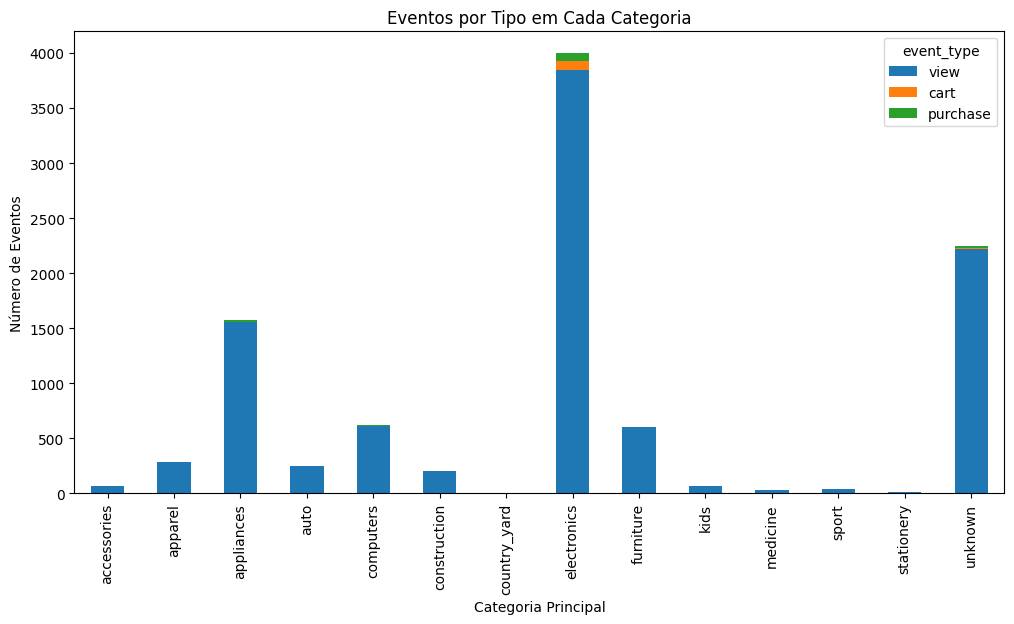

In [ ]:
category_event_counts[['view','cart','purchase']].plot(kind='bar', stacked=True, figsize=(12,6))
plt.ylabel("Número de Eventos")
plt.xlabel("Categoria Principal")
plt.title("Eventos por Tipo em Cada Categoria")
plt.show()

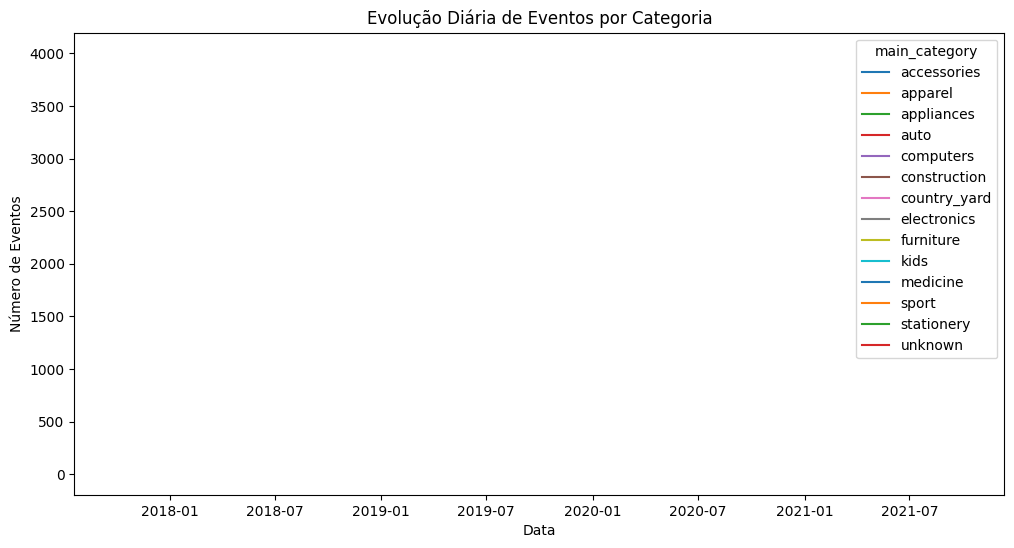

In [ ]:
df['date'] = pd.to_datetime(df['event_time']).dt.date
daily_category_events = df.groupby(['date','main_category']).size().unstack().fillna(0)

daily_category_events.plot(figsize=(12,6))
plt.ylabel("Número de Eventos")
plt.xlabel("Data")
plt.title("Evolução Diária de Eventos por Categoria")
plt.show()

## Data Understanding e Data Preparation: brand
Possibilidades:
* Identificação de quais marcas tem mais visualizações, adições ao carrinho de compras
* Identificação de quais marcas perdem clientes no funil
* Identificação de Sazonalidade de vendas
* Recomendações de marcas

In [ ]:
list(df.brand.unique())
print(df['brand'].value_counts())

brand
unknown       1442
samsung       1231
apple         1039
xiaomi         698
huawei         306
              ... 
fit              1
alcasta          1
maestro          1
altinbasak       1
mitasu           1
Name: count, Length: 672, dtype: int64


In [ ]:
# Tratamento de brand: para os valores ausentes (NaN) de 'brand',inferir à partir de 'product_id'
prod_map = df.dropna(subset=['brand']).drop_duplicates('product_id')
prod_map = dict(zip(prod_map['product_id'], prod_map['brand']))

df['brand'] = df.apply(lambda row: prod_map.get(row['product_id'], row['brand']), axis=1)

In [ ]:
# Tratamento de brand: para os valores ausentes (NaN) de 'brand', preencher com 'unknown'
df['brand'] = df['brand'].fillna('unknown')

In [ ]:
df['brand'].value_counts(normalize=True) * 100

,proportion
brand,
unknown,14.421442
samsung,12.311231
apple,10.391039
xiaomi,6.980698
huawei,3.060306
...,...
fit,0.010001
alcasta,0.010001
maestro,0.010001


In [ ]:
brand_counts = df.groupby(['brand','event_type']).size().unstack().fillna(0)
#brand_counts['view_to_cart_rate'] = brand_counts['cart'] / brand_counts['view'] * 100
brand_counts['view_to_cart_rate'] = (brand_counts['cart'] / brand_counts['view']) * 100
#brand_counts['cart_to_purchase_rate'] = brand_counts['purchase'] / brand_counts['cart'] * 100
brand_counts['cart_to_purchase_rate'] = (brand_counts['purchase'] / brand_counts['cart']) * 100
brand_counts

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate
brand,,,,,
a-case,0.0,0.0,3.0,0.0,NaN
a-elita,0.0,0.0,1.0,0.0,NaN
academie,0.0,0.0,1.0,0.0,NaN
acer,0.0,1.0,94.0,0.0,inf
acme,0.0,0.0,2.0,0.0,NaN
...,...,...,...,...,...
zemex,0.0,0.0,1.0,0.0,NaN
zeppelin,0.0,0.0,1.0,0.0,NaN
zerten,0.0,0.0,1.0,0.0,NaN


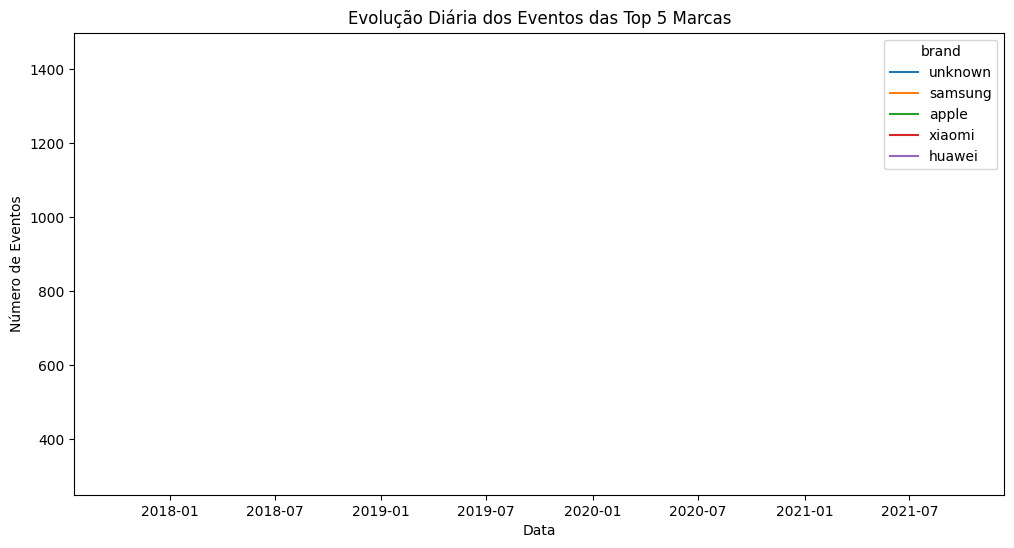

In [ ]:
total_events_per_brand = df['brand'].value_counts()
top5_brands = total_events_per_brand.head(5).index.tolist()

daily_brand_events = df.groupby(['date','brand']).size().unstack().fillna(0)
daily_top5 = daily_brand_events[top5_brands]

daily_top5.plot(figsize=(12,6))
plt.xlabel("Data")
plt.ylabel("Número de Eventos")
plt.title("Evolução Diária dos Eventos das Top 5 Marcas")
plt.show()

## Data Understanding e Data Preparation: price
Possibilidades:
* Análise taxa de compras por faixa de preço
* Identificação de outliers e erros de cadastro para ajuste
* Segmentação de clientes por faixas de preços e ticket médio
* Comparação de preço médio por categoria ou marca para ajuste de preço (melhoria de vendas ou margem de lucro)

In [ ]:
df['price'].describe()

,price
count,9999.000000
mean,294.098607
std,365.523534
min,0.000000
25%,62.940000
50%,159.330000
75%,362.940000
max,2574.070000


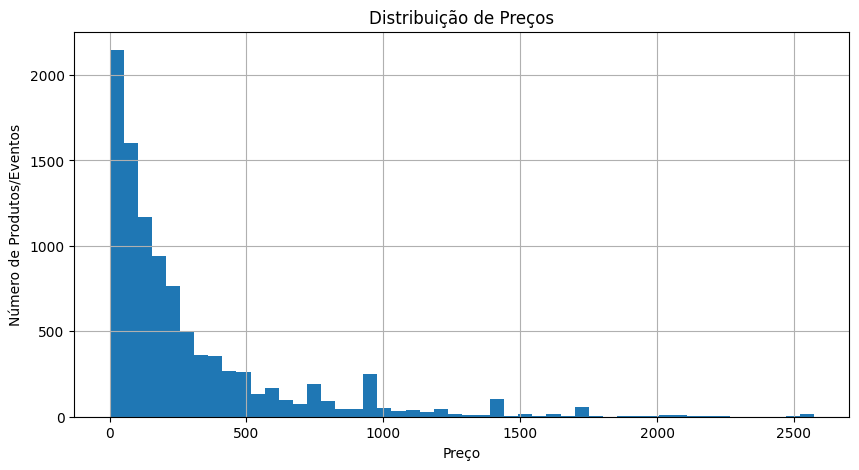

In [ ]:
df['price'].hist(bins=50, figsize=(10,5))
plt.xlabel("Preço")
plt.ylabel("Número de Produtos/Eventos")
plt.title("Distribuição de Preços")
plt.show()

In [ ]:
df.groupby('main_category')['price'].mean().sort_values(ascending=False)
df.groupby('brand')['price'].mean().sort_values(ascending=False)

,price
brand,
scott,2391.310
rado,2290.920
peda,2100.850
longines,1589.058
mercury,1586.140
...,...
tamish,3.600
wess,3.340
wuw,3.090


/tmp/ipython-input-448944997.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion = df.groupby(pd.cut(df['price'], bins=10))['event_type'].value_counts(normalize=True).unstack()


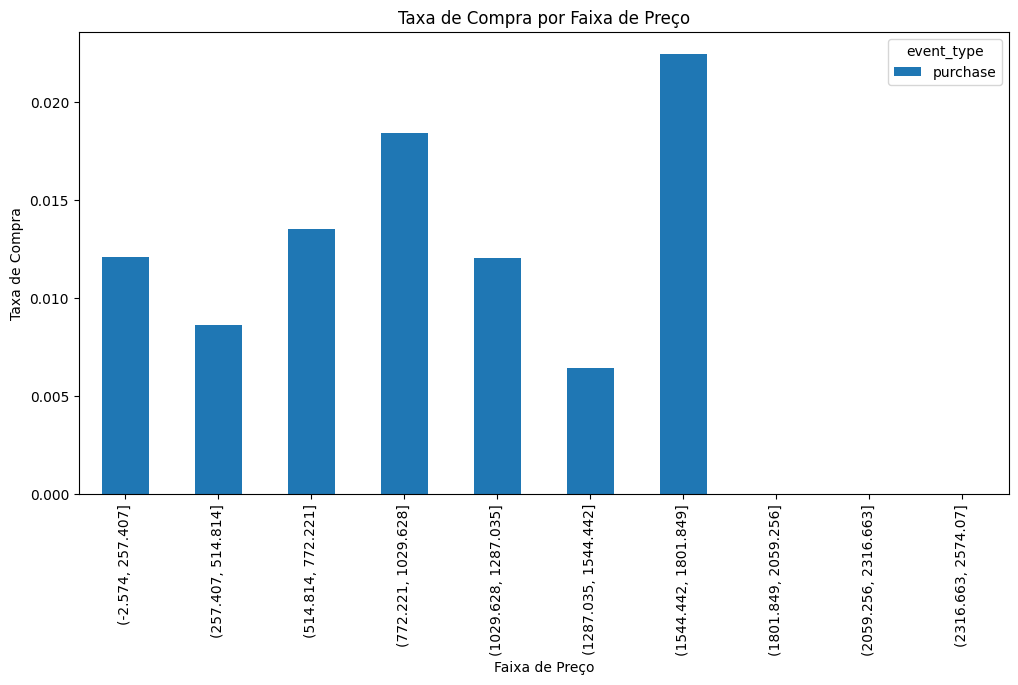

In [ ]:
conversion = df.groupby(pd.cut(df['price'], bins=10))['event_type'].value_counts(normalize=True).unstack()
conversion[['purchase']].plot(kind='bar', figsize=(12,6))
plt.xlabel("Faixa de Preço")
plt.ylabel("Taxa de Compra")
plt.title("Taxa de Compra por Faixa de Preço")
plt.show()

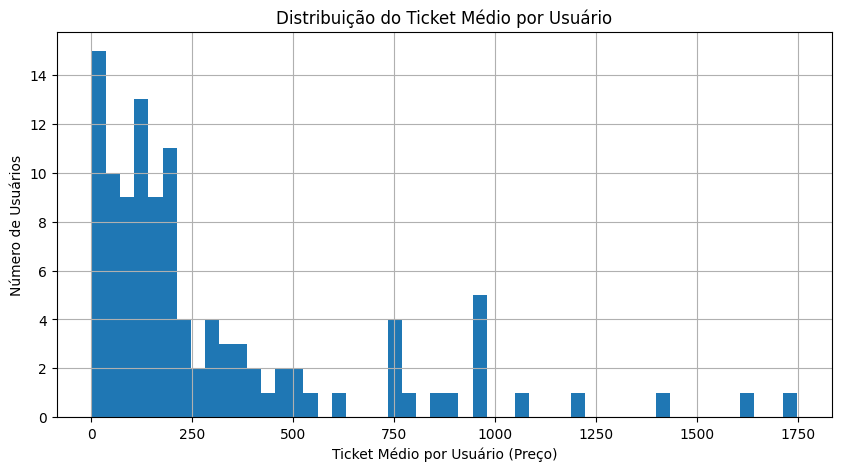

In [ ]:
df[df['event_type']=='purchase'].groupby('user_id')['price'].mean().hist(bins=50, figsize=(10,5))
plt.xlabel("Ticket Médio por Usuário (Preço)")
plt.ylabel("Número de Usuários")
plt.title("Distribuição do Ticket Médio por Usuário")
plt.show()

In [ ]:
df['price'].quantile([0.01,0.99])  # limites 1% e 99%

,price
0.01,5.1298
0.99,1747.7900


## Data Understanding e Data Preparation: user_id e user_session
Possibilidades:
* Análise de picos de tráfego com maior conversão
* Previsão de demanda futura (gerenciamento de estoque)
* Detecção de anomalias de tráfego (bots e problemas técnicos)
* Detecção de onde os usuários abandonam o funil de vendas

In [ ]:
list(df.user_session.unique())
print(df['user_session'].value_counts())

user_session
aa01487d-d46a-4704-9f1c-29613fbdaf1e    43
862d6815-ceac-4b6c-9baa-e99dfff0f40c    28
2885756b-57f6-487b-946d-8cac7ddc4b66    27
f7db7dad-ebfc-4f66-8ed4-45dfe8717261    25
05664614-7845-4809-ac08-970a912858d0    24
                                        ..
40cb886c-73ca-48d1-bcf4-41bbba3c2af1     1
1a23924d-1bd3-4e0b-9687-4ce0932a1705     1
e3151795-c355-4efa-acf6-e1fe1bebeee5     1
50a293fb-5940-41b2-baf3-17af0e812101     1
b5bdd0b3-4ca2-4c55-939e-9ce44bb50abd     1
Name: count, Length: 3188, dtype: int64


In [ ]:
# Agrupar por user_session e contar quantos user_id distintos existem
inconsistencias = (
    df.groupby("user_session")["user_id"]
      .nunique()
      .reset_index()
      .query("user_id > 1")   # pega apenas sessões com mais de 1 user_id
)
print(inconsistencias)

                             user_session  user_id
473  2759bd71-1333-4348-816d-c02912f6ebd4        2


In [ ]:
# Visualizar os registros originais que são inconsistentes
registros_inconsistentes = df[df["user_session"].isin(inconsistencias["user_session"])]
print(registros_inconsistentes)

                    event_time        date  hour  day  weekday  month  year  \
4750 2019-10-01 02:27:45+00:00  2019-10-01     2    1  Tuesday     10  2019   
5094 2019-10-01 02:28:27+00:00  2019-10-01     2    1  Tuesday     10  2019   

     event_type  product_id          category_id category_code      brand  \
4750       view    10300637  2053013553115300101       unknown  silverlit   
5094       view    10301026  2053013553115300101       unknown  silverlit   

      price    user_id                          user_session main_category  \
4750  14.39  555463297  2759bd71-1333-4348-816d-c02912f6ebd4       unknown   
5094  11.56  555463292  2759bd71-1333-4348-816d-c02912f6ebd4       unknown   

     sub_category  
4750         None  
5094         None  


<Axes: >

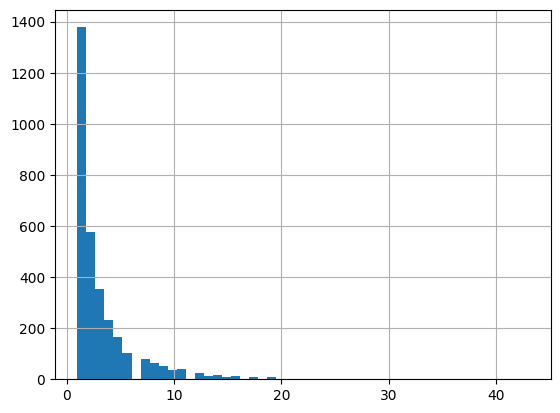

In [ ]:
events_per_session = df.groupby('user_session').size()
events_per_session.hist(bins=50)

<Axes: >

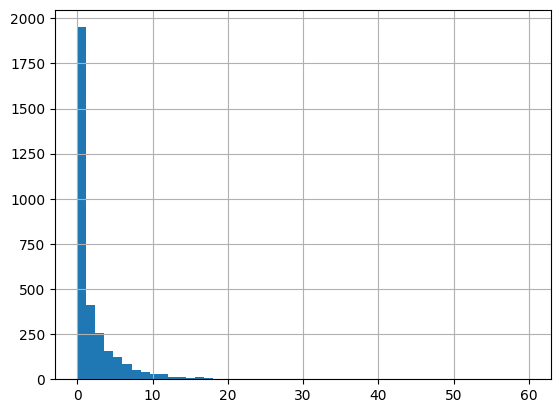

In [ ]:
session_time = df.groupby('user_session')['event_time'].agg(['min','max'])
session_time['duration_minutes'] = (session_time['max'] - session_time['min']).dt.total_seconds() / 60
session_time['duration_minutes'].hist(bins=50)

In [ ]:
session_events = df.groupby(['user_session','event_type']).size().unstack().fillna(0)
session_events

event_type,cart,purchase,view
user_session,,,
00334c2e-e8e5-463f-ae4e-f44f9796ccf4,0.0,0.0,2.0
006d2e99-7346-4240-b445-2d9cc21ffdfe,0.0,0.0,3.0
008d7f4b-ed7a-484b-88bd-b0aacd787fb7,0.0,0.0,1.0
009074dd-dda3-4032-9e3e-b45fed5fa579,0.0,0.0,1.0
0090a953-4885-db5f-97aa-8a89b7adbbfb,0.0,0.0,1.0
...,...,...,...
ffc72f0a-6428-5bdd-9032-90c2067bc115,0.0,0.0,1.0
ffecf7c3-5348-49cd-aa68-419a8654367e,0.0,0.0,3.0
ffeda3e8-e3d1-4345-b585-3dc601692fa2,0.0,0.0,2.0


<Axes: >

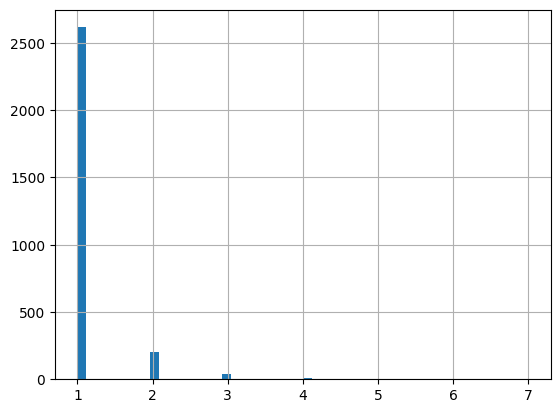

In [ ]:
sessions_per_user = df.groupby('user_id')['user_session'].nunique()
sessions_per_user.hist(bins=50)

In [ ]:
# Tempo médio entre sessões
df_sorted = df.sort_values(['user_id','event_time'])
df_sorted['prev_session'] = df_sorted.groupby('user_id')['event_time'].shift(1)
df_sorted['time_since_last'] = (df_sorted['event_time'] - df_sorted['prev_session']).dt.total_seconds() / 3600
df_sorted.head()

,event_time,date,hour,day,weekday,month,year,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category,sub_category,prev_session,time_since_last
1150,2019-10-01 01:32:09+00:00,2019-10-01,1,1,Tuesday,10,2019,view,2501614,2053013564003713919,appliances.kitchen.oven,redmond,164.71,306441847,47641f8a-3aba-471a-8d07-014deccec567,appliances,kitchen.oven,NaT,NaN
2774,2019-10-01 02:23:02+00:00,2019-10-01,2,1,Tuesday,10,2019,view,7202317,2053013553165631753,unknown,lego,24.45,400972610,a6b41834-75dd-4cd5-ace6-cbe1a4fe54df,unknown,None,NaT,NaN
2936,2019-10-01 02:23:27+00:00,2019-10-01,2,1,Tuesday,10,2019,view,7203226,2053013553165631753,unknown,lego,44.45,400972610,a6b41834-75dd-4cd5-ace6-cbe1a4fe54df,unknown,None,2019-10-01 02:23:02+00:00,0.006944
3063,2019-10-01 02:23:49+00:00,2019-10-01,2,1,Tuesday,10,2019,view,7203227,2053013553165631753,unknown,lego,24.45,400972610,a6b41834-75dd-4cd5-ace6-cbe1a4fe54df,unknown,None,2019-10-01 02:23:27+00:00,0.006111
3106,2019-10-01 02:23:56+00:00,2019-10-01,2,1,Tuesday,10,2019,view,7203226,2053013553165631753,unknown,lego,44.45,400972610,a6b41834-75dd-4cd5-ace6-cbe1a4fe54df,unknown,None,2019-10-01 02:23:49+00:00,0.001944


In [ ]:
# Conversão por sessão
purchased_sessions = df[df['event_type']=='purchase']['user_session'].nunique()
total_sessions = df['user_session'].nunique()
conversion_rate = purchased_sessions / total_sessions * 100
conversion_rate

3.4818067754077795

In [ ]:
df.groupby(['user_session','main_category']).size().unstack().fillna(0)

main_category,accessories,apparel,appliances,auto,computers,construction,country_yard,electronics,furniture,kids,medicine,sport,stationery,unknown
user_session,,,,,,,,,,,,,,
00334c2e-e8e5-463f-ae4e-f44f9796ccf4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
006d2e99-7346-4240-b445-2d9cc21ffdfe,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
008d7f4b-ed7a-484b-88bd-b0aacd787fb7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
009074dd-dda3-4032-9e3e-b45fed5fa579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0090a953-4885-db5f-97aa-8a89b7adbbfb,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffc72f0a-6428-5bdd-9032-90c2067bc115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ffecf7c3-5348-49cd-aa68-419a8654367e,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ffeda3e8-e3d1-4345-b585-3dc601692fa2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## Mapa de Calor

In [ ]:
heatmap_data = pd.crosstab(df['main_category'], df['event_type'])

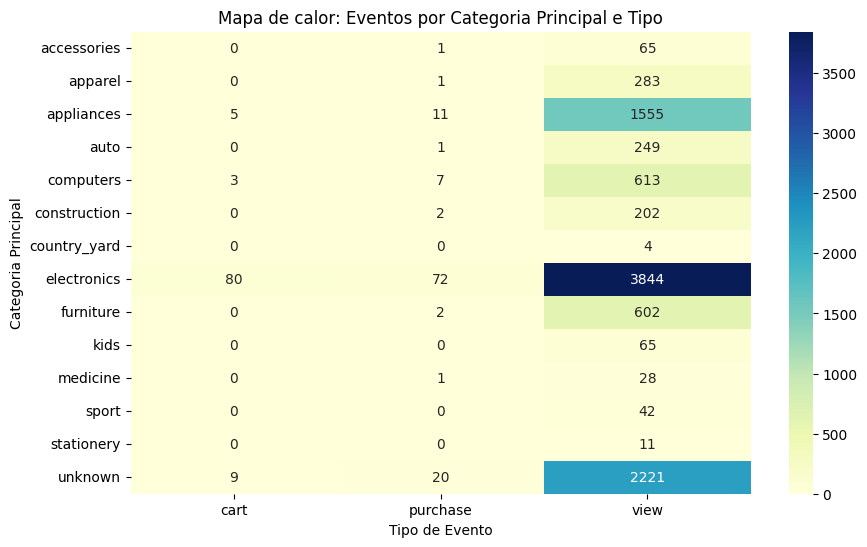

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Mapa de calor: Eventos por Categoria Principal e Tipo")
plt.ylabel("Categoria Principal")
plt.xlabel("Tipo de Evento")
plt.show()

In [ ]:
numeric_cols = df[['price','category_id']] # user_id ficou de fora
corr = numeric_cols.corr()

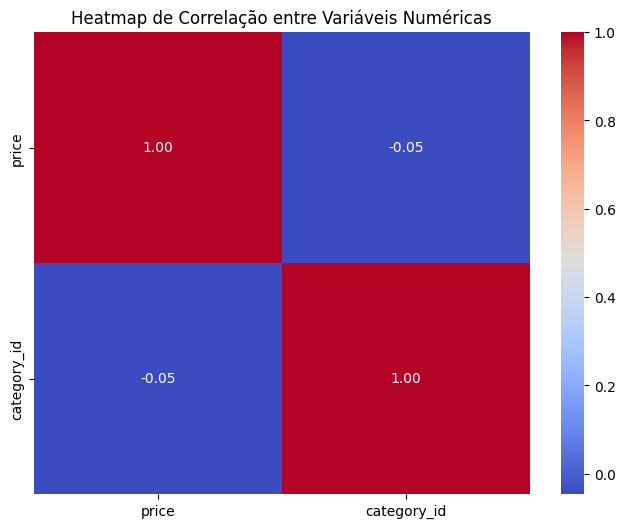

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de Correlação entre Variáveis Numéricas")
plt.show()

In [ ]:
price_by_category = df.groupby('main_category')['price'].mean().sort_values(ascending=False)

In [ ]:
# Filtrar apenas eventos de compra
purchase_df = df[df['event_type'] == 'purchase']

# Contar compras por categoria principal
top5_categories = purchase_df['main_category'].value_counts().head(5).index.tolist()
print(top5_categories)

['electronics', 'unknown', 'appliances', 'computers', 'construction']


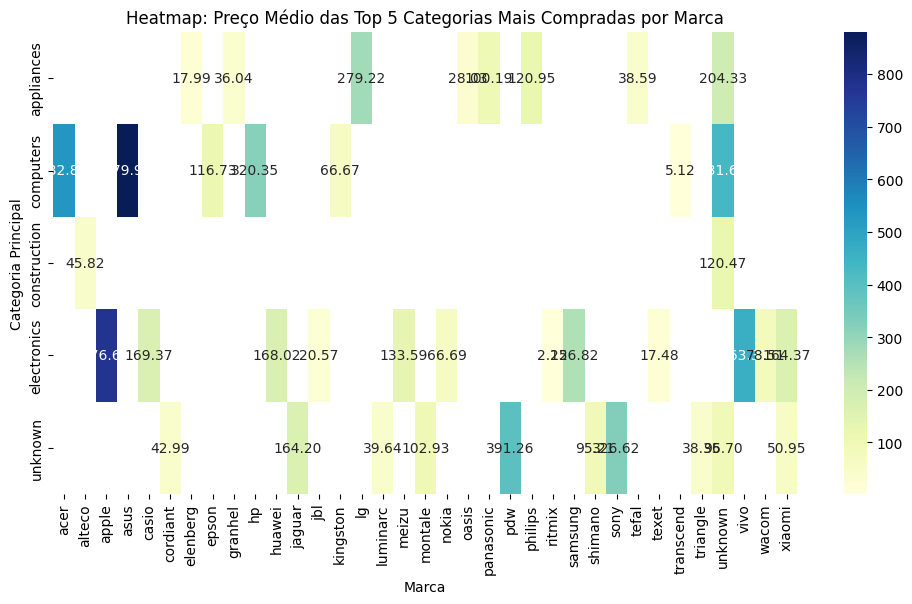

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = purchase_df[purchase_df['main_category'].isin(top5_categories)]

# Heatmap Data - Pivot table: main_category x brand → número de compras
heatmap_data2 = heatmap_data.pivot_table(
    index='main_category',
    columns='brand',
    values='price',  # para preço médio, ou 'user_id' para contar compras
    aggfunc='mean'   # 'count' se quiser contagem de compras
)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data2, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap: Preço Médio das Top 5 Categorias Mais Compradas por Marca")
plt.xlabel("Marca")
plt.ylabel("Categoria Principal")
plt.show()

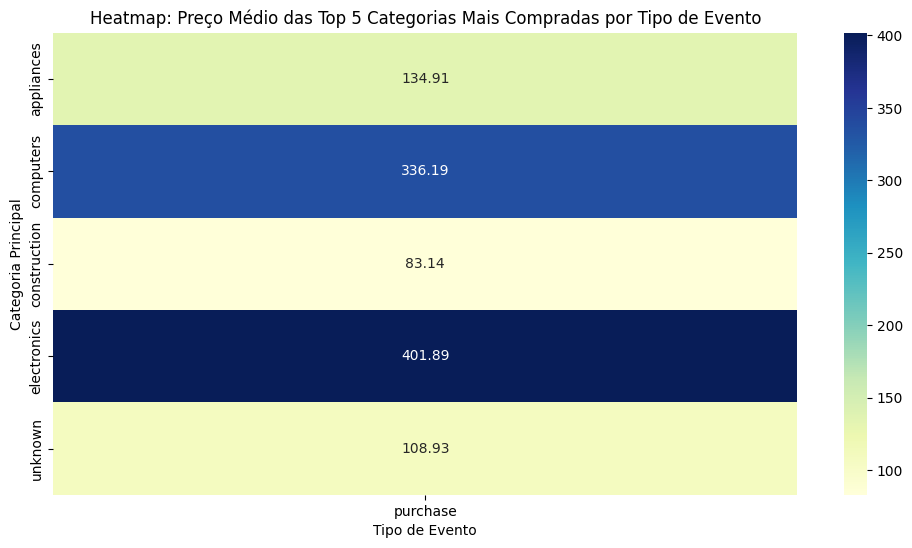

In [ ]:
# Heatmap Data - Pivot table: main_category x event_type → número de compras
heatmap_data3 = heatmap_data.pivot_table(
    index='main_category',
    columns='event_type',
    values='price',  # para preço médio, ou 'user_id' para contar compras
    aggfunc='mean'   # 'count' se quiser contagem de compras
)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data3, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap: Preço Médio das Top 5 Categorias Mais Compradas por Tipo de Evento")
plt.xlabel("Tipo de Evento")
plt.ylabel("Categoria Principal")
plt.show()

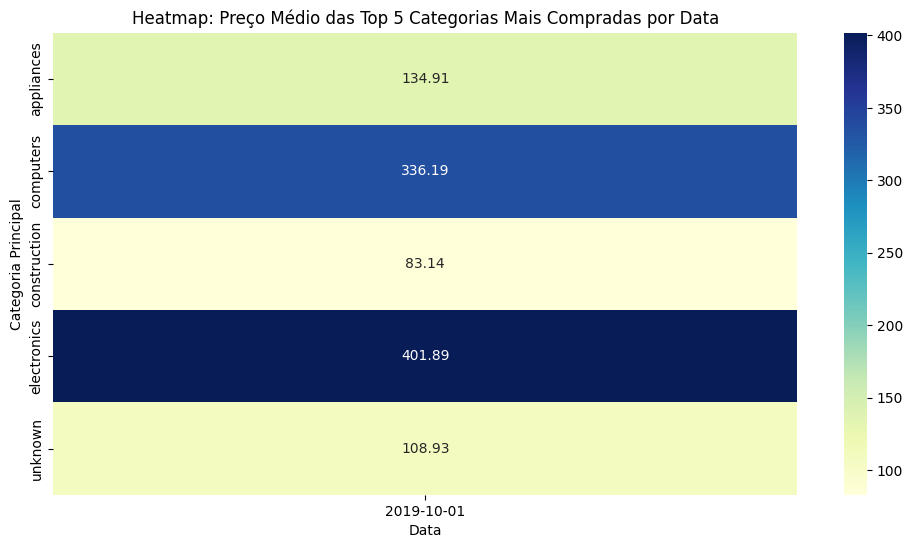

In [ ]:
# Heatmap Data - Pivot table: main_category x date → número de compras
heatmap_data4 = heatmap_data.pivot_table(
    index='main_category',
    columns='date',
    values='price',  # para preço médio, ou 'user_id' para contar compras
    aggfunc='mean'   # 'count' se quiser contagem de compras
)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data4, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap: Preço Médio das Top 5 Categorias Mais Compradas por Data")
plt.xlabel("Data")
plt.ylabel("Categoria Principal")
plt.show()

## Tarefas para Machine Learning sugeridos
* Classificação - Target categórica: previsão se uma sessão vai resultar em compra; previsão de churn ou abandono; preços fora do padrão;
* Regressão - Target numérica: previsão de preço de produto, com base na concorrência (marca); ticket médio por perfil de usuário; previsão de vendas diárias; tráfego por sessão;
* Agrupamento: grupos de clientes mais rentáveis; grupos de produtos para planejamento de oferta;

### Vou trabalhar em:

* Modelo 1 - Classificação - Preços fora do Padrão
* Modelo 2 - Agrupamento - Grupos de Clientes mais Rentáveis


## Modelo 1 - Classificação - Preços fora do Padrão
### Classes: outlier=1 (preço fora do padrão); outlier=0 (preço normal)

In [ ]:
df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
def outlier_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return ~group.between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [ ]:
df['outlier'] = df.groupby('category_id')['price'].transform(outlier_iqr).astype(int)

In [ ]:
df['price_ratio_cat'] = df.groupby('category_id')['price'].transform(lambda x: x / x.mean())
df = df[df["price_ratio_cat"].notnull()]
#df.isnull().sum()

In [ ]:
X = df[['price', 'price_ratio_cat']]
y = df['outlier']

# Split e treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print(X.shape)
print(y.shape)

(9997, 2)
(9997,)


In [ ]:
print(X.shape)
print(y.shape)

(9997, 2)
(9997,)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Avaliação Conj. Testes (X_test)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2839
           1       0.82      0.48      0.60       161

    accuracy                           0.97      3000
   macro avg       0.90      0.74      0.79      3000
weighted avg       0.96      0.97      0.96      3000



In [ ]:
# Avaliação Conj. Treinamento (X_train)
y_pred2 = model.predict(X_train)
print(classification_report(y_train, y_pred2))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      6595
           1       0.89      0.55      0.68       402

    accuracy                           0.97      6997
   macro avg       0.93      0.77      0.83      6997
weighted avg       0.97      0.97      0.97      6997



In [ ]:
import numpy as np
y_combined = list(zip(y_pred, y_pred2))
print(y_pred.shape)
print(y_pred2.shape)
print(X.shape)
y_combined = np.concatenate([y_pred, y_pred2])
print(y_combined.shape)

(3000,)
(6997,)
(9997, 2)
(9997,)


In [ ]:
X['oulier previsto'] = y_combined
X

/tmp/ipython-input-1648757875.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['oulier previsto'] = y_combined


,price,price_ratio_cat,oulier previsto
0,35.79,1.000000,0
1,33.20,0.251767,0
2,543.10,1.019559,0
3,251.74,0.356822,0
4,1081.98,2.176353,0
...,...,...,...
9994,27.03,0.632914,0
9995,59.18,0.932458,1
9996,25.48,3.165217,0
9997,179.38,0.360815,0


## Modelo 2 - Agrupamento - Grupos de Clientes mais Rentáveis
### Com base no Comportamento do Cliente:
* Segmentação de Clientes mais Rentáveis - abordagem RFM; Recency (tempo desde última compra), Frequency (número de compras) e Monetary (total gasto)
* Custo de Serviço - muitos cart (carrinhos) abandonados (muitos carts e poucos purchase, baixa conversão) ou muitos view sem compra

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from datetime import datetime

# Carregar dados
# df.head()
df.isnull().sum()


,0
event_time,0
date,0
hour,0
day,0
weekday,0
month,0
year,0
event_type,0
product_id,0
category_id,0


In [ ]:
# Preenchimento de sub_category com ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separar dados com sub_category preenchido
df_train = df[df["sub_category"].notnull()]
df_test = df[df["sub_category"].isnull()]

X_train = pd.get_dummies(df_train[["category_id","brand","price"]])
y_train = df_train["sub_category"]

X_test = pd.get_dummies(df_test[["category_id","brand","price"]])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # alinhar colunas

# Treinar modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Preencher os valores faltantes
df.loc[df["sub_category"].isnull(), "sub_category"] = model.predict(X_test)

In [ ]:
df.isnull().sum()

,0
event_time,0
date,0
hour,0
day,0
weekday,0
month,0
year,0
event_type,0
product_id,0
category_id,0


In [ ]:
# Filtrar apenas compras
purchases = df[df["event_type"] == "purchase"]

In [ ]:
# Agregar por cliente
agg = purchases.groupby("user_id").agg(
    total_spent=("price", "sum"),
    frequency=("product_id", "count"),
    last_purchase=("event_time", "max")
).reset_index()

# Recency (em dias)
agg["last_purchase"] = pd.to_datetime(agg["last_purchase"])
max_date = pd.to_datetime(df["event_time"]).max()
agg["recency_days"] = (max_date - agg["last_purchase"]).dt.days
# Substituir NaN por 1000 (para indicar que não é recente para os product_id e event_time não encontrados)
agg["recency_days"] = agg["recency_days"].fillna(1000)
X.isnull().sum()


,0
price,0
price_ratio_cat,0
oulier previsto,0


In [ ]:
# Normalizar features
X = agg[["total_spent", "frequency", "recency_days"]]
X.isnull().sum()


,0
total_spent,0
frequency,0
recency_days,0


In [ ]:
X_scaled = (X - X.mean()) / X.std()
X_scaled["recency_days"] = X_scaled["recency_days"].fillna(1000)
X_scaled.isnull().sum()


,0
total_spent,0
frequency,0
recency_days,0


In [ ]:
# Clusterização
kmeans = KMeans(n_clusters=4, random_state=42)
agg['cluster'] = kmeans.fit_predict(X_scaled)

# Identificar cluster mais lucrativo
cluster_summary = agg.groupby("cluster").agg(
    avg_spent=("total_spent","mean"),
    total_spent=("total_spent","sum"),
    customers=("user_id","count")
)
print(cluster_summary.sort_values("total_spent", ascending=False))

           avg_spent  total_spent  customers
cluster                                     
1        1001.027059     17017.46         17
0         167.486071     14068.83         84
2         388.541429      2719.79          7
3        1951.140000      1951.14          1


In [ ]:
df = df.merge(agg[["user_id", "cluster"]], on="user_id", how="left") # Alguns user_id não estão atribuidos à nenhum cluster por não terem registro de venda

In [ ]:
df.head()

,event_time,date,hour,day,weekday,month,year,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category,sub_category,outlier,price_ratio_cat,cluster
0,2019-10-01 00:00:00+00:00,2019-10-01,0,1,Tuesday,10,2019,view,44600062,2103807459595387724,unknown,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,unknown,iron,0,1.000000,NaN
1,2019-10-01 00:00:00+00:00,2019-10-01,0,1,Tuesday,10,2019,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,appliances,environment.water_heater,0,0.251767,NaN
2,2019-10-01 00:00:01+00:00,2019-10-01,0,1,Tuesday,10,2019,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,furniture,living_room.sofa,0,1.019559,NaN
3,2019-10-01 00:00:01+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,computers,notebook,0,0.356822,NaN
4,2019-10-01 00:00:04+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,electronics,smartphone,0,2.176353,NaN


In [ ]:
df_valid = df[df["cluster"].notnull()]
df_valid.head()

,event_time,date,hour,day,weekday,month,year,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category,sub_category,outlier,price_ratio_cat,cluster
51,2019-10-01 00:00:41+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1003141,2053013555631882655,electronics.smartphone,apple,382.97,551377651,ca11a570-47da-4630-898b-9a03127703da,electronics,smartphone,0,0.770326,2.0
127,2019-10-01 00:01:45+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1003305,2053013555631882655,electronics.smartphone,apple,612.43,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68,electronics,smartphone,0,1.231875,2.0
129,2019-10-01 00:01:46+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564,electronics,smartphone,0,0.263018,0.0
152,2019-10-01 00:02:08+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1002528,2053013555631882655,electronics.smartphone,apple,643.23,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68,electronics,smartphone,0,1.293827,2.0
156,2019-10-01 00:02:11+00:00,2019-10-01,0,1,Tuesday,10,2019,view,1307073,2053013558920217191,computers.notebook,acer,669.00,514805015,ae211ff5-7e3e-4a19-9bf6-bb7e19421843,computers,notebook,0,0.948256,0.0
